Imports

In [35]:
%pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Consistent aesthetics
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


load and clean

In [10]:
# --- Load ---
# The CSV has a two-row header: row 0 names the pathogen group,
# row 1 provides the year label. We skip row 0 and assign names manually.
df = pd.read_csv('ThreeYearVirusData.csv', skiprows=1)

df.columns = [
    'Sample_Name', 'Location', 'Cultivar', 'Block', 'Tree_Number', 'Row', 'Tree',
    'PDV_Y1',   'PDV_Y2',   'PDV_Y3',
    'PNRSV_Y1', 'PNRSV_Y2', 'PNRSV_Y3',
    'PLMVd_Y1', 'PLMVd_Y2', 'PLMVd_Y3',
]

print(f"Shape: {df.shape}")
df.head(3)


Shape: (2408, 16)


,Sample_Name,Location,Cultivar,Block,Tree_Number,Row,Tree,PDV_Y1,PDV_Y2,PDV_Y3,PNRSV_Y1,PNRSV_Y2,PNRSV_Y3,PLMVd_Y1,PLMVd_Y2,PLMVd_Y3
0,AP B-1 5351,Edgefield,Augustprince,B-1,5351,1,10,-,-,-,-,-,-,-,-,-
1,AP B-1 5352,Edgefield,Augustprince,B-1,5352,1,9,-,-,-,-,-,-,-,-,-
2,AP B-1 5353,Edgefield,Augustprince,B-1,5353,1,8,-,-,-,-,-,-,-,-,-


In [11]:
# --- Binary-encode the 9 virus test columns (+/- -> 1/0) ---
VIRUS_COLS = [
    'PDV_Y1',   'PDV_Y2',   'PDV_Y3',
    'PNRSV_Y1', 'PNRSV_Y2', 'PNRSV_Y3',
    'PLMVd_Y1', 'PLMVd_Y2', 'PLMVd_Y3',
]
for col in VIRUS_COLS:
    df[col + '_bin'] = (df[col] == '+').astype(int)

# --- Encode Location ---z
le_loc = LabelEncoder()
df['Location_enc'] = le_loc.fit_transform(df['Location'])

# --- Encode Cultivar: top-10 + "Other" ---
top10_cultivars = df['Cultivar'].value_counts().head(10).index.tolist()
df['Cultivar_grp'] = df['Cultivar'].apply(lambda x: x if x in top10_cultivars else 'Other')
le_cult = LabelEncoder()
df['Cultivar_enc'] = le_cult.fit_transform(df['Cultivar_grp'])

# --- Numeric position columns ---
df['Row_num']  = pd.to_numeric(df['Row'],  errors='coerce').fillna(df['Row'].value_counts().index[0])
df['Tree_num'] = pd.to_numeric(df['Tree'], errors='coerce').fillna(0)

print("Missing values:", df.isnull().sum().sum())
print("Class distribution — PLMVd Year 3:")
print(df['PLMVd_Y3_bin'].value_counts().rename({0:'Negative', 1:'Positive'}))


Missing values: 21
Class distribution — PLMVd Year 3:
PLMVd_Y3_bin
Negative    2263
Positive     145
Name: count, dtype: int64


Feature Matrix

In [12]:
# Features used for clustering and dimensionality reduction.
# We include all available prior-year virus data plus metadata.
# PLMVd_Y3_bin is the TARGET — kept in df for coloring but NOT in X.
FEATURE_COLS = [
    'PLMVd_Y1_bin', 'PLMVd_Y2_bin',
    'PDV_Y1_bin',   'PDV_Y2_bin',
    'PNRSV_Y1_bin', 'PNRSV_Y2_bin',
    'Location_enc', 'Cultivar_enc',
    'Row_num', 'Tree_num',
]

X_raw = df[FEATURE_COLS].values
y     = df['PLMVd_Y3_bin'].values  # used only for coloring

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Feature matrix: {X.shape}")
print(f"Positive (PLMVd Y3): {y.sum()} / {len(y)}  ({y.mean()*100:.1f}%)")


Feature matrix: (2408, 10)
Positive (PLMVd Y3): 145 / 2408  (6.0%)


In [15]:
n_samples, n_features = X.shape

pca = PCA(n_components=X.shape[1])
X_transformed = pca.fit_transform(X)

# We center the data and compute the sample covariance matrix.
X_centered = X - np.mean(X, axis=0)
cov_matrix = np.dot(X_centered.T, X_centered) / n_samples
eigenvalues = pca.explained_variance_
for i, (eigenvalue, eigenvector) in enumerate(zip(eigenvalues, pca.components_)):
    print(f"\nPC{i+1} — eigenvalue: {eigenvalue:.6f}")
    print(f"  verification dot product: {np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)):.6f}")
    for feature, loading in zip(FEATURE_COLS, eigenvector):
        print(f"  {feature}: {loading:.6f}")


PC1 — eigenvalue: 2.529481
  verification dot product: 2.528431
  PLMVd_Y1_bin: -0.078959
  PLMVd_Y2_bin: -0.049347
  PDV_Y1_bin: 0.546011
  PDV_Y2_bin: 0.543127
  PNRSV_Y1_bin: 0.302569
  PNRSV_Y2_bin: 0.368080
  Location_enc: -0.232562
  Cultivar_enc: 0.167357
  Row_num: -0.217887
  Tree_num: -0.204002

PC2 — eigenvalue: 1.720199
  verification dot product: 1.719485
  PLMVd_Y1_bin: 0.548946
  PLMVd_Y2_bin: 0.494504
  PDV_Y1_bin: 0.079002
  PDV_Y2_bin: 0.070512
  PNRSV_Y1_bin: 0.231469
  PNRSV_Y2_bin: 0.216561
  Location_enc: 0.256970
  Cultivar_enc: 0.226221
  Row_num: 0.332693
  Tree_num: 0.338440

PC3 — eigenvalue: 1.397845
  verification dot product: 1.397264
  PLMVd_Y1_bin: 0.407273
  PLMVd_Y2_bin: 0.516783
  PDV_Y1_bin: -0.066535
  PDV_Y2_bin: -0.065216
  PNRSV_Y1_bin: -0.156444
  PNRSV_Y2_bin: -0.175564
  Location_enc: -0.338315
  Cultivar_enc: -0.095025
  Row_num: -0.336304
  Tree_num: -0.516237

PC4 — eigenvalue: 1.235823
  verification dot product: 1.235309
  PLMVd_Y1_bin: 

Split data for pca analysis

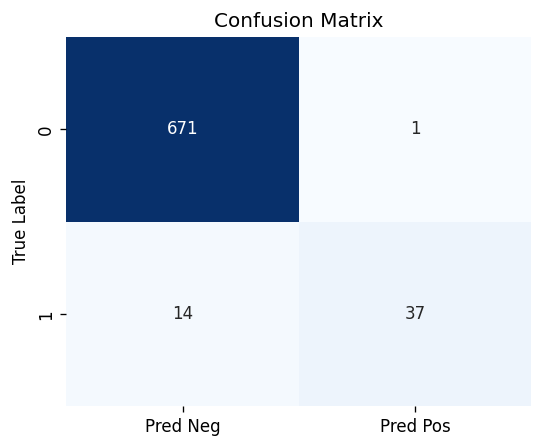

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Neg', 'Pred Pos'],)
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

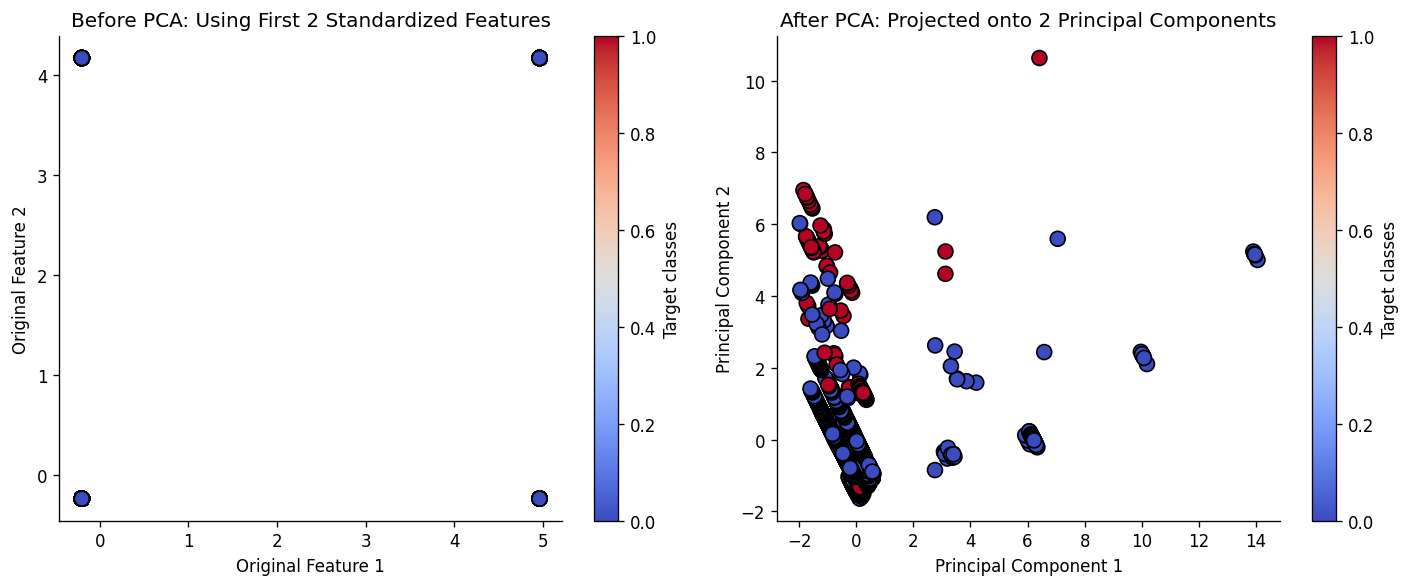

In [22]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

In [37]:
# Compute Recall
r_data = recall_score(y_test, y_pred)

# Compute Precision
p_data = precision_score(y_test, y_pred)

# Compute F1-Score
f1 = f1_score(y_test, y_pred)

# Print results
print("Recall:", r_data, "\n")
print("Precision:", p_data, "\n")
print("F1-Score:", f1, "\n")

Recall: 0.7254901960784313 

Precision: 0.9736842105263158 

F1-Score: 0.8314606741573034 

